In [1]:
from typing import Callable, List, Optional, Tuple, Union

import scanpy as sc
import scvelo as scv
import anndata as ad
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import matplotlib
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

import pandas as pd
import numpy as np
import pickle
from sklearn import preprocessing
import json
import torch
from torch import nn
from torch.autograd.functional import jacobian
import os
from torchdiffeq import odeint
from sklearn.decomposition import PCA
from scipy.stats import pearsonr, linregress
from sklearn.metrics.pairwise import cosine_similarity
from scipy.io import loadmat, savemat
from scipy.interpolate import interp1d
from scipy.optimize import OptimizeResult, minimize
from scipy.integrate import odeint as solveode
import dynamo as dyn
dyn.dynamo_logger.main_silence()
sc.settings.set_figure_params(dpi=80, dpi_save=300, fontsize=14)
plt.rcParams['axes.grid'] = False
plt.rcParams['svg.fonttype']='none'
plt.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings('ignore')

In [2]:
def arrowed_spines(ax, columns, background="white"):
    """
    画左下角箭头的函数，引自dynamo
    """
    if type(columns) == str:
        columns = [columns.upper() + " 1", columns.upper() + " 2"]
    import matplotlib.pyplot as plt

    fig = plt.gcf()

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    # removing the default axis on all sides:
    despline_all(ax)

    # removing the axis ticks
    deaxis_all(ax)

    # get width and height of axes object to compute
    # matching arrowhead length and width
    dps = fig.dpi_scale_trans.inverted()
    bbox = ax.get_window_extent().transformed(dps)
    width, height = bbox.width, bbox.height

    # manual arrowhead width and length (x-axis)
    hw = 1.0 / 20.0 * (ymax - ymin)
    hl = 1.0 / 20.0 * (xmax - xmin)
    lw = 1.0  # axis line width
    ohg = 0.2  # arrow overhang

    # compute matching arrowhead length and width (y-axis)
    yhw = hw / (ymax - ymin) * (xmax - xmin) * height / width
    yhl = hl / (xmax - xmin) * (ymax - ymin) * width / height

    # draw x and y axis
    fc, ec = ("w", "w") if background in ["black", "#ffffff"] else ("k", "k")
    ax.arrow(
        xmin,
        ymin,
        hl * 5 / 2,
        0,
        fc=fc,
        ec=ec,
        lw=lw,
        head_width=hw / 2,
        head_length=hl / 2,
        overhang=ohg / 2,
        length_includes_head=True,
        clip_on=False,
    )
    ax.arrow(
        xmin,
        ymin,
        0,
        hw * 5 / 2,
        fc=fc,
        ec=ec,
        lw=lw,
        head_width=yhw / 2,
        head_length=yhl / 2,
        overhang=ohg / 2,
        length_includes_head=True,
        clip_on=False,
    )

    ax.text(
        xmin + hl * 2.5 / 2,
        ymin - 1.5 * hw / 2,
        columns[0],
        ha="center",
        va="center",
        rotation=0,
        # size=hl * 5 / (2 * len(str(columns[0]))) * 20,
        # size=matplotlib.rcParams['axes.titlesize'],
        size=np.clip((hl + yhw) * 8 / 2, 6, 18),
    )
    ax.text(
        xmin - 1.5 * yhw / 2,
        ymin + hw * 2.5 / 2,
        columns[1],
        ha="center",
        va="center",
        rotation=90,
        # size=hw * 5 / (2 * len(str(columns[1]))) * 20,
        # size=matplotlib.rcParams['axes.titlesize'],
        size=np.clip((hl + yhw) * 8 / 2, 6, 18),
    )

    return ax

def despline_all(ax=None, sides=None):
    # removing the default axis on all sides:
    import matplotlib.pyplot as plt

    ax = plt.gca() if ax is None else ax

    if sides is None:
        sides = ["bottom", "right", "top", "left"]
    for side in sides:
        ax.spines[side].set_visible(False)


def deaxis_all(ax=None):
    # removing the axis ticks
    import matplotlib.pyplot as plt

    ax = plt.gca() if ax is None else ax

    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

In [3]:
## 真实向量场
def F(x,t):
    F = np.zeros(44)
    (AP1, pRB, pRBc1, pRBp, pRBc2, pRBpp, E2F, E2Fp, Cd, Mdi, Md, Mdp27, Ce, Mei, Me, Skp2, Mep27, Pei, Pe, Ca, Mai, Ma, Map27, 
    p27, p27p, Cdh1i, Cdh1a, Pai, Pa, Cb, Mbi, Mb, Mbp27, Cdc20i, Cdc20a, Pbi, Pb, Wee1, Wee1p, Cdc45, Pol, Primer, ATR, Chk1) = x
    
    ## 模型参数设置
    Mw = 0;
    GF = 1; Kagf = 0.1; kdap1 = 0.15; ep = 17; vsap1 = 1;
    kde2f = 0.002; kde2fp = 1.1; kdprb = 0.01; kdpRBp = 0.06; kdpRBpp = 0.04; 
    kpc1 = 0.05; kpc2 = 0.5; kpc3 = 0.025; kpc4 = 0.5;
    K1 = 0.1 ; K2 = 0.1 ; K3 = 0.1; K4 = 0.1 ;
    V1 = 2.2; V2 = 2; V3 = 1; V4 = 2;
    K1e2f = 5 ; K2e2f = 5 ; V1e2f = 4; V2e2f = 0.75 ; vse2f = 0.15 ; 
    vsprb = 0.8 ;
    Cdk4tot = 1.5 ; Ki7 = 0.1 ; Ki8 = 2 ; kcd1 = 0.4 ; kcd2 = 0.005 ;
    kdecom1 = 0.1 ; kcom1 = 0.175 ; kc1 = 0.15 ; kc2 = 0.05 ;
    kddd = 0.005 ; Kdd = 0.1 ; K1d = 0.1 ; K2d = 0.1 ; Vdd = 5; Vm1d = 1; 
    Vm2d = 0.2;
    ae = 0.25; Cdk2tot = 2; ib1 = 0.5; Ki9 = 0.1; Ki10 = 2; kce = 0.29;
    kc3 = 0.2 ; kc4 = 0.1 ; kdecom2 = 0.1 ; kcom2 = 0.2 ; kdde = 0.005 ; 
    kddskp2 = 0.005 ;
    kdpe = 0.075 ; kdpei = 0.15 ; Kde = 0.1 ; Kdceskp2 = 2 ; Kdskp2 = 0.5 ; Kcdh1 = 0.4 ;
    K1e = 0.1 ; K2e = 0.1 ; K5e = 0.1 ; K6e = 0.1 ; Vde = 3 ; Vdskp2 = 1.1 ;
    Vm1e = 2 ; Vm2e = 1.4 ; Vm5e = 5 ; V6e = 0.8 ; vspei = 0.13 ; vsskp2 = 0.15 ;
    xe1 = 1; xe2 = 1;
    aax = 0.2 ; ib2 = 0.5 ; Ki11 = 0.1 ; Ki12 = 2 ; Ki13 = 0.1 ; Ki14 = 2 ;
    kca = 0.0375 ; kdecom3 = 0.1 ; kcom3 = 0.2 ;
    kc5 = 0.15 ; kc6 = 0.125 ; kdda = 0.005 ; kddp27 = 0.06 ; kddp27p = 0.01 ;
    kdcdh1a = 0.1 ; kdcdh1i = 0.2 ; kdpa = 0.075 ; kdpai = 0.15 ; Kda = 1.1 ; Kdp27p = 0.1 ;
    Kdp27skp2 = 0.1 ; Kacdc20 = 2 ;
    K1a = 0.1 ; K2a = 0.1 ; K1cdh1 = 0.01 ; K2cdh1 = 0.01 ;
    K5a = 0.1 ; K6a = 0.1 ; K1p27 = 0.5 ; K2p27 = 0.5 ; Vdp27p = 5 ;
    Vda = 2.5 ; Vm1a = 2 ; Vm2a = 1.85 ; Vm5a = 4 ; V6a = 1; vscdh1a = 0.11; vspai = 0.105 ;
    vs1p27 = 0.8 ; vs2p27 = 0.1 ; V1cdh1 = 1.25 ; V2cdh1 = 8 ; V1p27 = 100 ; V2p27 = 0.1 ;
    xa1 = 1; xa2 = 1;
    ab = 0.11 ; Cdk1tot = 0.5 ;
    ib = 0.75 ; ib3 = 0.5 ; kc7 = 0.12 ; kc8 = 0.2; kdecom4 = 0.1 ; kcom4 = 0.25 ;
    kdcdc20a = 0.05 ; kdcdc20i = 0.14 ; kddb = 0.005 ; kdpb = 0.1 ; kdpbi = 0.2 ;
    kdwee1 = 0.1 ; kdwee1p = 0.2 ; Kdb = 0.005 ; Kdbcdc20 = 0.2 ; Kdbcdh1 = 0.1;
    ksw = 5 ; K1b = 0.1 ; K2b = 0.1 ; K3b = 0.1 ; K4b = 0.1 ; K5b = 0.1 ; K6b = 0.1 ; K7b = 0.1 ; K8b = 0.1 ; vcb = 0.05 ; Vdb = 0.06 ; Vm1b = 3.9 ; Vm2b = 2.1 ;
    vscdc20i = 0.1 ; Vm3b = 8; Vm4b = 0.7 ; Vm5b = 5 ; V6b = 1 ; Vm7b = 1.2 ; Vm8b = 1 ; vspbi = 0.12 ; vswee1 = 0.06 ; xb1 = 1; xb2 = 1; 
    ATRtot = 0.5 ; Chk1tot = 0.5 ; Cdc45tot = 0.5 ;
    kaatr = 0.022;
    kdatr = 0.15 ; kdpol = 0.2 ;
    kdprim = 0.15 ; kspol = 0.8 ; ksprim = 0.05 ; K1cdc45 = 0.02 ; K2cdc45 = 0.02 ;
    K1chk = 0.5 ; K2chk = 0.5 ; Poltot = 0.5 ; V1cdc45 = 0.8 ; V2cdc45 = 0.12 ; V1chk = 4 ; V2chk = 0.1 ;
    
    ## 方程
    F[0] = (vsap1* (GF/(Kagf + GF)) - kdap1 *AP1) * ep
    F[1] = (vsprb - kpc1 * pRB* E2F + kpc2 * pRBc1 - V1 * (pRB/( K1 + pRB)) * (Md + Mdp27) + V2*(pRBp/( K2 + pRBp)) - kdprb * pRB) * ep
    F[2] = (kpc1*pRB*E2F - kpc2*pRBc1)*ep
    F[3] = (V1 *(pRB/(K1 + pRB)) * (Md + Mdp27) - V2 * (pRBp/(K2 + pRBp)) - V3 * (pRBp/( K3 + pRBp)) * Me + V4 * (pRBpp/( K4 + pRBpp)) - kpc3 * pRBp* E2F + kpc4 * pRBc2 - kdpRBp * pRBp) * ep
    F[4] = (kpc3 * pRBp* E2F - kpc4 * pRBc2) * ep
    F[5] = (V3 * (pRBp/(K3 + pRBp)) * Me - V4 * (pRBpp/(K4 + pRBpp)) - kdpRBpp * pRBpp)*ep
    F[6] = (vse2f - kpc1 * pRB* E2F + kpc2 * pRBc1 - kpc3 * pRBp* E2F + kpc4 * pRBc2- V1e2f * Ma* (E2F/( K1e2f + E2F)) + V2e2f * (E2Fp/( K2e2f + E2Fp)) - kde2f * E2F) * ep
    F[7] = (V1e2f * Ma* (E2F/(K1e2f + E2F)) -  V2e2f * (E2Fp/( K2e2f + E2Fp)) - kde2fp * E2Fp) * ep
    F[8] = (kcd1 * AP1 +  kcd2 * E2F * (Ki7/(Ki7 + pRB)) * (Ki8/( Ki8 + pRBp)) -  kcom1 * Cd * (Cdk4tot - (Mdi + Md + Mdp27)) + kdecom1 * Mdi - Vdd * (Cd/( Kdd + Cd)) - kddd * Cd) * ep
    F[9] = (kcom1 * Cd * (Cdk4tot - (Mdi + Md + Mdp27)) -  kdecom1 * Mdi + Vm2d * (Md/( K2d + Md)) - Vm1d * (Mdi/(K1d + Mdi))) * ep
    F[10] = (Vm1d * (Mdi/(K1d + Mdi)) - Vm2d * (Md/( K2d + Md)) - kc1 * Md* p27 + kc2 * Mdp27) * ep
    F[11] = (kc1 * Md* p27 - kc2 * Mdp27) * ep
    F[12] = (kce * E2F * (Ki9 /(Ki9 + pRB)) * (Ki10/(Ki10 + pRBp))- kcom2 * Ce * (Cdk2tot - (Mei + Me + Mep27 + Mai + Ma + Map27))+ kdecom2 * Mei - Vde * (Skp2/(Kdceskp2 + Skp2)) * (Ce/( Kde + Ce)) - kdde * Ce) * ep
    F[13] = (kcom2 * Ce * (Cdk2tot - (Mei + Me + Mep27 + Mai + Ma + Map27)) - kdecom2 * Mei + Vm2e * (Wee1 + ib1) * (Me/(K2e + Me)) - Vm1e * Pe * (Mei/(K1e + Mei))) * ep
    F[14] = (Vm1e * Pe * (Mei/( K1e + Mei)) - Vm2e * (Wee1 + ib1) * (Me/( K2e + Me)) - kc3 * Me* p27 +  kc4 * Mep27) * ep
    F[15] = (vsskp2 - Vdskp2 * (Skp2/(Kdskp2 + Skp2)) * (Cdh1a/(Kcdh1 + Cdh1a)) - kddskp2 * Skp2) * ep
    F[16] = (kc3 * Me* p27 - kc4 * Mep27) * ep
    F[17] = (vspei + V6e * (xe1 + xe2 * Chk1) * (Pe/(K6e + Pe)) - Vm5e * (Me + ae) * (Pei/(K5e + Pei)) - kdpei * Pei) * ep
    F[18] = (Vm5e * (Me + ae) * (Pei/(K5e + Pei))- V6e * (xe1 + xe2 * Chk1) * (Pe/( K6e + Pe)) - kdpe * Pe) * ep
    F[19] = (kca * E2F * (Ki11/( Ki11 + pRB)) * (Ki12/(Ki12 + pRBp))- kcom3 * Ca* (Cdk2tot - (Mei + Me + Mep27 + Mai + Ma + Map27))+ kdecom3 * Mai - Vda * (Ca/(Kda + Ca)) * (Cdc20a/( Kacdc20 + Cdc20a)) - kdda * Ca) * ep
    F[20] = (kcom3 * Ca* (Cdk2tot - (Mei + Me + Mep27 + Mai + Ma + Map27)) -  kdecom3 * Mai + Vm2a * (Wee1 + ib2) * (Ma/(K2a + Ma)) - Vm1a * Pa* (Mai/(K1a + Mai))) * ep
    F[21] = (Vm1a * Pa* (Mai/( K1a + Mai)) - Vm2a * (Wee1 + ib2) * (Ma/( K2a + Ma)) - kc5 * Ma* p27 + kc6 * Map27) * ep
    F[22] = (kc5 * Ma* p27 - kc6 * Map27) * ep
    F[23] = (vs1p27 +  vs2p27 * E2F * (Ki13/( Ki13 + pRB)) * (Ki14/(Ki14 + pRBp)) -  kc1 * Md * p27 + kc2 * Mdp27 - kc3 * Me* p27 + kc4 * Mep27 - kc5 * Ma* p27 + kc6 * Map27 - kc7 * Mb* p27 + kc8 * Mbp27 - V1p27 * Me* (p27/(K1p27 + p27)) + V2p27 * (p27p/( K2p27 + p27p)) - kddp27 * p27) * ep
    F[24] = (V1p27 * Me* (p27/(K1p27 + p27)) - V2p27 * (p27p/(K2p27 + p27p)) - Vdp27p * (Skp2/( Kdp27skp2 + Skp2)) * (p27p/(Kdp27p + p27p)) - kddp27p * p27p) * ep
    F[25] = (V2cdh1 * (Cdh1a/( K2cdh1 + Cdh1a)) * (Ma + Mb) - V1cdh1 * (Cdh1i/( K1cdh1 + Cdh1i)) - kdcdh1i * Cdh1i) * ep
    F[26] = (vscdh1a + V1cdh1 * (Cdh1i/(K1cdh1 + Cdh1i)) - V2cdh1 * (Cdh1a/( K2cdh1 + Cdh1a)) * (Ma + Mb) - kdcdh1a * Cdh1a) * ep
    F[27] = (vspai + V6a * (xa1 + xa2 * Chk1) * (Pa /(K6a + Pa)) - Vm5a * (Ma + aax ) * (Pai/( K5a + Pai)) - kdpai * Pai) * ep
    F[28] = (Vm5a * (Ma + aax) * (Pai/( K5a + Pai)) -  V6a * (xa1 + xa2 * Chk1) * (Pa/(K6a + Pa)) - kdpa * Pa) * ep
    F[29] = (vcb - kcom4 * Cb* (Cdk1tot - (Mbi + Mb + Mbp27)) + kdecom4 * Mbi - Vdb * (Cb/( Kdb + Cb)) *((Cdc20a/(  Kdbcdc20 + Cdc20a)) + (Cdh1a/(Kdbcdh1 + Cdh1a))) - kddb * Cb) * ep
    F[30] = (kcom4 * Cb* (Cdk1tot - (Mbi + Mb + Mbp27)) - kdecom4 * Mbi +  Vm2b * (Wee1 + ib3 ) * (Mb/( K2b + Mb)) - Vm1b * Pb* (Mbi/( K1b + Mbi))) * ep
    F[31] = (Vm1b * Pb* (Mbi/(K1b + Mbi)) - Vm2b * (Wee1 + ib3) * (Mb/(K2b + Mb)) - kc7 * Mb* p27 +  kc8 * Mbp27) * ep
    F[32] = (kc7 * Mb* p27 - kc8 * Mbp27) * ep
    F[33] = (vscdc20i - Vm3b * Mb* (Cdc20i/( K3b + Cdc20i)) + Vm4b * (Cdc20a/( K4b + Cdc20a))- kdcdc20i * Cdc20i) * ep
    F[34] = (Vm3b * Mb* (Cdc20i/(K3b + Cdc20i)) - Vm4b * (Cdc20a/( K4b + Cdc20a))- kdcdc20a * Cdc20a) * ep
    F[35] = (vspbi + V6b * (xb1 + xb2 * Chk1) * (Pb/(K6b + Pb)) - Vm5b * (Mb + ab) * (Pbi/(K5b + Pbi)) - kdpbi * Pbi) * ep
    F[36] = (Vm5b * (Mb + ab) * (Pbi/(K5b + Pbi))- V6b * (xb1 + xb2 * Chk1) * (Pb/( K6b + Pb)) - kdpb * Pb) * ep
    F[37] = (vswee1 + ksw * Mw - Vm7b * (Mb + ib) * (Wee1/(K7b + Wee1)) + Vm8b * (Wee1p/( K8b + Wee1p)) - kdwee1 *Wee1) * ep
    F[38] = (Vm7b * (Mb + ib ) * (Wee1/( K7b + Wee1)) - Vm8b * (Wee1p/(K8b + Wee1p)) - kdwee1p *Wee1p) * ep
    F[39] = (V1cdc45 * Me* ((Cdc45tot - Cdc45)/( K1cdc45 + (Cdc45tot - Cdc45))) -  V2cdc45 * (Cdc45/(K2cdc45 + Cdc45)) - kspol * (Poltot - Pol) * Cdc45 + kdpol * Pol) * ep
    F[40] = (kspol * (Poltot - Pol) * Cdc45 - kdpol * Pol) * ep
    F[41] = (ksprim * Pol - kdprim * Primer - kaatr * (ATRtot - ATR) * Primer + kdatr * ATR) * ep
    F[42] = (kaatr * (ATRtot - ATR) * Primer - kdatr * ATR) * ep
    F[43] = (V1chk * ATR* ((Chk1tot - Chk1)/(K1chk + (Chk1tot - Chk1))) - V2chk * (Chk1/( K2chk + Chk1))) * ep
    
    return F

In [4]:
class Encoder(nn.Module):
    def __init__(
        self,
        n_int: int,
        n_latent: int = 20,
        n_hidden: int = 32,
        batch_norm: bool = False,
    ):
        super().__init__()

        self.fc1 = nn.Sequential()
        self.fc1.add_module('L1', nn.Linear(n_int, n_hidden))
        if batch_norm:
            self.fc1.add_module('N1', nn.BatchNorm1d(n_hidden))
        self.fc1.add_module('A1', nn.LeakyReLU())
        self.fc2_mean = nn.Linear(n_hidden, n_latent)
        self.fc2_logvar = nn.Linear(n_hidden, n_latent)

    def forward(self, x: torch.Tensor):
        x = self.fc1(x)
        mean = self.fc2_mean(x)
        logvar = self.fc2_logvar(x)
        return mean, logvar

class Decoder(nn.Module):
    def __init__(
        self,
        n_int: int,
        n_latent: int = 20,
        n_hidden: int = 32,
        batch_norm: bool = False,
    ):
        super().__init__()
        self.fc1 = nn.Sequential()
        self.fc1.add_module('L1', nn.Linear(n_latent, n_hidden))
        if batch_norm:
            self.fc1.add_module('N1', nn.BatchNorm1d(n_hidden))
        # self.fc1.add_module('A1', nn.LeakyReLU())
        self.fc2 = nn.Linear(n_hidden, n_int)

    def forward(self, z: torch.Tensor):
        z = self.fc1(z)
        recon_x = self.fc2(z)
        return recon_x

class LatentODE(nn.Module):
    def __init__(
        self,
        n_latent: int = 20,
        n_hidden: int = 32,
    ):
        super(LatentODE, self).__init__()

        self.layer1 = nn.Sequential(
            nn.Linear(in_features=n_latent, out_features=n_hidden, bias=True),
            nn.ELU())

        self.layer2 = nn.Sequential(
            nn.Linear(in_features=n_hidden, out_features=n_hidden, bias=True),
            nn.BatchNorm1d(n_hidden),
            nn.ELU())

        self.layer4 = nn.Sequential(
            nn.Linear(in_features=n_hidden, out_features=n_latent, bias=True)
            )

    def forward(self, t, x):
        fc1 = self.layer1(x)
        fc2 = self.layer2(fc1)
        output = self.layer4(fc2)
        return output

In [5]:
## 加载训练好的模型
encoder = Encoder(n_int=44)
decoder = Decoder(n_int=44)
dynamics_learner = LatentODE()
dynamics_learner.load_state_dict(torch.load('Parameters_dynamics.pickle', map_location=torch.device('cpu')))
encoder.load_state_dict(torch.load('Parameters_encoder.pickle', map_location=torch.device('cpu')))
decoder.load_state_dict(torch.load('Parameters_decoder.pickle', map_location=torch.device('cpu')))
dynamics_learner.eval()
encoder.eval()
decoder.eval()

Decoder(
  (fc1): Sequential(
    (L1): Linear(in_features=20, out_features=32, bias=True)
  )
  (fc2): Linear(in_features=32, out_features=44, bias=True)
)

In [6]:
## 读取数据
with open('data_with_phase.pickle', 'rb') as f:
    adata = pickle.load(f)
adata.shape

(8000, 45)

In [7]:
## 转换为伪时间
percentiles = np.percentile(adata[:,-1], np.linspace(0, 100, 1000))
indices = np.digitize(adata[:,-1], percentiles)
pseudotime = indices * 0.001

In [8]:
th=pseudotime
minima = min(th)
maxima = max(th)
norm = matplotlib.colors.Normalize(vmin=minima, vmax=maxima)
mapper = cm.ScalarMappable(norm=norm, cmap=cm.viridis)

In [9]:
## 按伪时间分为4个phase
thresholds = [0.14, 0.49, 0.84]
types = np.digitize(pseudotime, thresholds)
phase_labels = ['G0/G1', 'S', 'G2', 'M']
phase = [phase_labels[t] for t in types]

tab10_colors = plt.cm.tab10.colors
color_dict = {
    'G0/G1': tab10_colors[1],
    'S': tab10_colors[6],
    'G2': tab10_colors[3],
    'M': tab10_colors[4]
}

# 指定颜色
phase_colors = [color_dict[p] for p in phase]

In [10]:
## 归一化细胞数据
np_data0 = adata[:, :-1]

np_data = (np_data0 - np_data0.min(0))/(np_data0.max(0) - np_data0.min(0))
# np_data = (np_data0 - np_data0.mean(0))/np_data0.std(0)

np_data.shape

(8000, 44)

Text(0.5, 1.0, 'CycE_CycA')

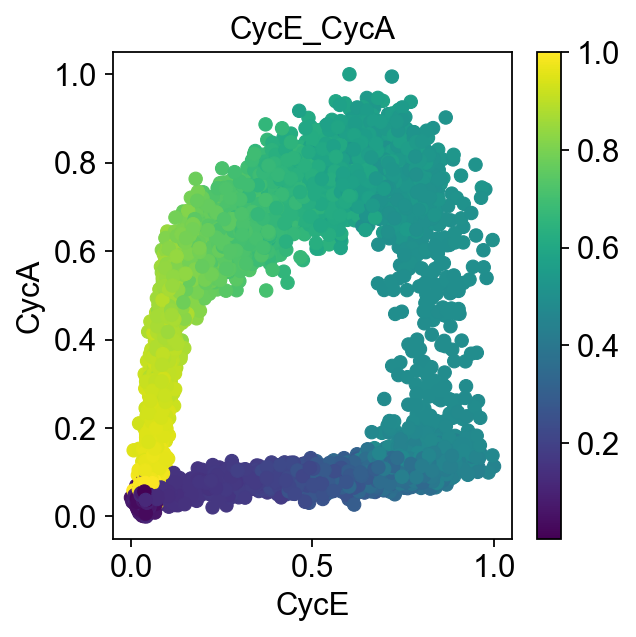

In [11]:
index1 = 14
index2 = 21
plt.scatter(np_data[:, index1], np_data[:, index2],c=th,cmap=cm.viridis)
plt.colorbar(mapper, ax=plt.gca())
plt.xlabel('CycE')
plt.ylabel('CycA')
plt.title('CycE_CycA')
# plt.savefig('1.png', dpi=300)

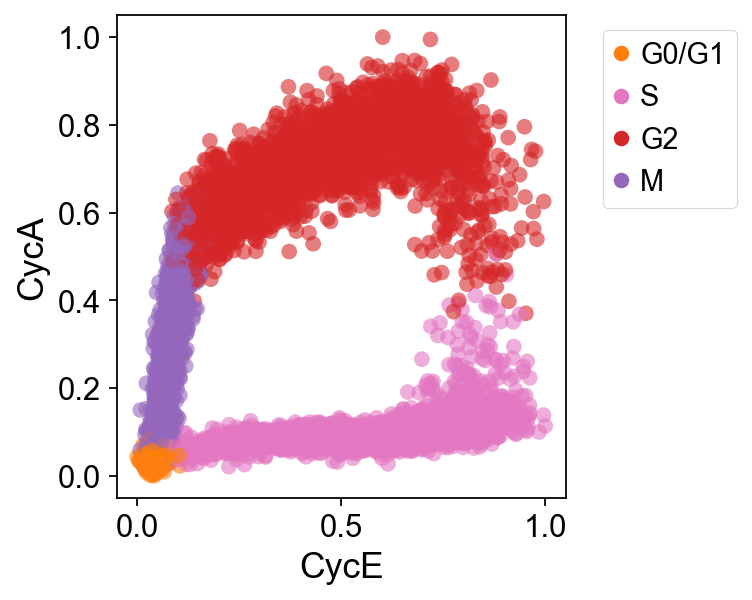

In [12]:
index1 = 14
index2 = 21

plt.figure(figsize=(5, 4))
plt.scatter(np_data[:, index1], np_data[:, index2], c=phase_colors, s=50, alpha=0.6, edgecolors='none', rasterized=True)

handles = [Line2D([0], [0], marker='o', color='w',
                  markerfacecolor=color_dict[label], markersize=8, label=label)
           for label in phase_labels]
plt.legend(handles=handles, title='', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=13)
plt.xlabel('CycE', fontsize=16)
plt.ylabel('CycA', fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=14)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig('figures/CycE_CycA_phase.svg', bbox_inches='tight', transparent=True, dpi=300)
plt.show()

In [13]:
## 计算重构及潜表示
raw = torch.as_tensor(np_data, dtype=torch.float32)
latent, _ = encoder(raw)
mean = latent.mean(0).detach()
std = latent.std(0).detach()
latent_std = torch.exp(0.5 * encoder(raw)[1])
reconstruct = decoder(latent)

raw = raw.detach().numpy()
reconstruct = reconstruct.detach().numpy()
latent = latent.detach().numpy()
latent_std = latent_std.detach().numpy()

In [14]:
latent_std.mean(0)

array([0.00361453, 0.00402632, 0.00354081, 0.00261856, 0.0059406 ,
       0.00388049, 0.00299448, 0.00353468, 0.0038427 , 0.00333422,
       0.00431111, 0.00231843, 0.00298358, 0.00277057, 0.00223002,
       0.00518914, 0.00363347, 0.99920475, 0.00460885, 0.99857616],
      dtype=float32)

In [15]:
pca = PCA(n_components=2)
pca.fit(latent)
V = pca.components_.T
ratio = pca.explained_variance_ratio_
latent_pca = (latent - np.mean(latent, axis=0)) @ V

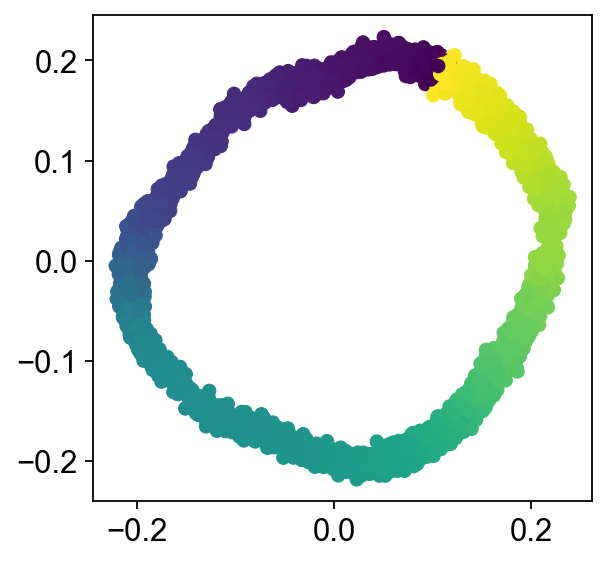

In [16]:
plt.scatter(latent_pca[:, 0], latent_pca[:, 1],c=th,cmap=cm.viridis)

In [17]:
## 对隐空间坐标标准化
latent_z = (latent - latent.mean(0))/latent.std(0)

# savemat('latent_z.mat', {'latent_z': np.hstack((latent_z, types[:, np.newaxis]))}) ## 保存，用于绘制景观时比较

In [18]:
## 计算velocity
velocity = np.zeros_like(latent)
for i in range(velocity.shape[0]):
    x0 = latent_z[i, :].reshape(1,-1)
    x1 = torch.as_tensor(x0, dtype=torch.float32)
    f = dynamics_learner(0, x1)
    v = f.detach().numpy()
    velocity[i, :] = np.squeeze(v)

In [19]:
## 对标准化latent坐标PCA降维
pca = PCA(n_components=2)
pca.fit(latent_z)
V = pca.components_.T
ratio = pca.explained_variance_ratio_
latent_z_pca = (latent_z - np.mean(latent_z, axis=0)) @ V

# 得到速率投影
v_pca = velocity @ V
v_norm = (v_pca.T/np.linalg.norm(v_pca, axis=1)).T

In [20]:
cwd = os.getcwd()
print("[Current working directory]:",cwd)
AE_dir = cwd+'/AE_fit/'
if not os.path.exists(AE_dir):
    os.makedirs(AE_dir)

[Current working directory]: D:\ROG\desktop\振荡动力学推断结果整理\code\44dim_cell_cycle


In [21]:
# for index in range(44):
#     fig, axes = plt.subplots(1,2,figsize=(12, 5))
#     sns.scatterplot(x=adata[:,-1], y=raw[:, index], alpha=0.1, ax=axes[0])
#     axes[0].set_title(str(index)+'_raw')
#     axes[0].set_ylabel('raw')
#     axes[0].set_ylim(-0.1, 1.1)
#     sns.scatterplot(x=adata[:,-1], y=reconstruct[:, index], alpha=0.1, ax=axes[1])
#     axes[1].set_title(str(index)+'_reconstruct')
#     axes[1].set_ylabel('reconstruct')
#     axes[1].set_ylim(-0.1, 1.1)
#     plt.savefig(AE_dir+str(index)+'.png')
#     plt.clf()

In [22]:
# for t in range(20):
#     fig, ax = plt.subplots()
#     sns.scatterplot(x=adata[:,-1],y=latent[:, t],alpha=0.1,ax=ax)
#     ax.set_title(t)
#     ax.set_ylabel('latent_rep')
#     plt.savefig(AE_dir+'latent_'+str(t)+'_rep.png')
#     plt.clf()
#     fig, ax = plt.subplots()
#     sns.scatterplot(x=adata[:,-1],y=latent_std[:, t],alpha=0.1,ax=ax)
#     ax.set_title(t)
#     ax.set_ylabel('latent_std')
#     plt.savefig(AE_dir+'latent_'+str(t)+'_std.png')
#     plt.clf()

In [23]:
# set initial points
# kk = 0.5
# x0 = np.ones((1, 44))*kk
x0 = np_data[0,:].reshape(-1,44)

# the length of sequence we predict
NK = 10000

t = torch.arange(0, 0.005 * NK, 0.005)

xx = np.zeros((44, NK))

x1 = torch.as_tensor(x0, dtype=torch.float32)
encoded, _ = encoder(x1)
encoded = (encoded - mean)/std

latent_t = odeint(dynamics_learner, encoded, t, method='rk4')
latent_t = latent_t.permute(1, 2, 0).squeeze() # ode的解

for i in range(NK):
    encoded = latent_t[:, i]
    encoded = encoded * std + mean
    x0 = decoder(encoded)
    x0 = x0.detach().numpy()
    xx[:, i] = x0
    
latent_t = latent_t.detach().numpy()

In [24]:
## 获得真实稳态解
point0 = np.array([0.01, 1, 0.25, 0.1, 0.01, 0.01, 0.1, 0.05, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 
                   0.01, 0.25, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.1, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01])

t2 = np.arange(0, 300, 0.01)
xx_true = solveode(F, point0, t2)

xx_true = ((xx_true - np_data0.min(0))/(np_data0.max(0) - np_data0.min(0))).T

xx_true_tensor = torch.as_tensor(xx_true.T, dtype=torch.float32)
latent_true, _ = encoder(xx_true_tensor)
latent_true = (latent_true - mean)/std
latent_true = latent_true.detach().numpy().T

In [25]:
## 对基因怕排序，绘制热力图
gene_names = ['AP1', 'pRB', 'pRBc1', 'pRBp', 'pRBc2', 'pRBpp', 'E2F', 'E2Fp', 'Cd', 'Mdi', 
              'Md', 'Mdp27', 'Ce', 'Mei', 'Me', 'Skp2', 'Mep27', 'Pei', 'Pe', 'Ca', 'Mai', 
              'Ma', 'Map27', 'p27', 'p27p', 'Cdh1i', 'Cdh1a', 'Pai', 'Pa', 'Cb', 'Mbi', 
              'Mb', 'Mbp27', 'Cdc20i', 'Cdc20a', 'Pbi', 'Pb', 'Wee1', 'Wee1p', 'Cdc45', 
              'Pol', 'Primer', 'ATR', 'Chk1']

cycle_true = xx_true[:, 24300:27180]
peak_times = np.argmax(cycle_true, axis=1)

sorted_idx = np.argsort(peak_times)
cycle_true_sorted = cycle_true[sorted_idx, :]
gene_names_sorted = [gene_names[i] for i in sorted_idx]

cycle_VAE = xx[:,9010:9508]

# # 找到最小距离的索引作为起始点
# target = cycle_true[:, 0]
# distances = np.linalg.norm(cycle_VAE - target[:, np.newaxis], axis=0)

# min_index = np.argmin(distances)

cycle_VAE_sorted = cycle_VAE[sorted_idx, :]

vmin = min(cycle_true_sorted.min(), cycle_VAE_sorted.min())
vmax = max(cycle_true_sorted.max(), cycle_VAE_sorted.max()) # 用于对齐颜色

<Axes: >

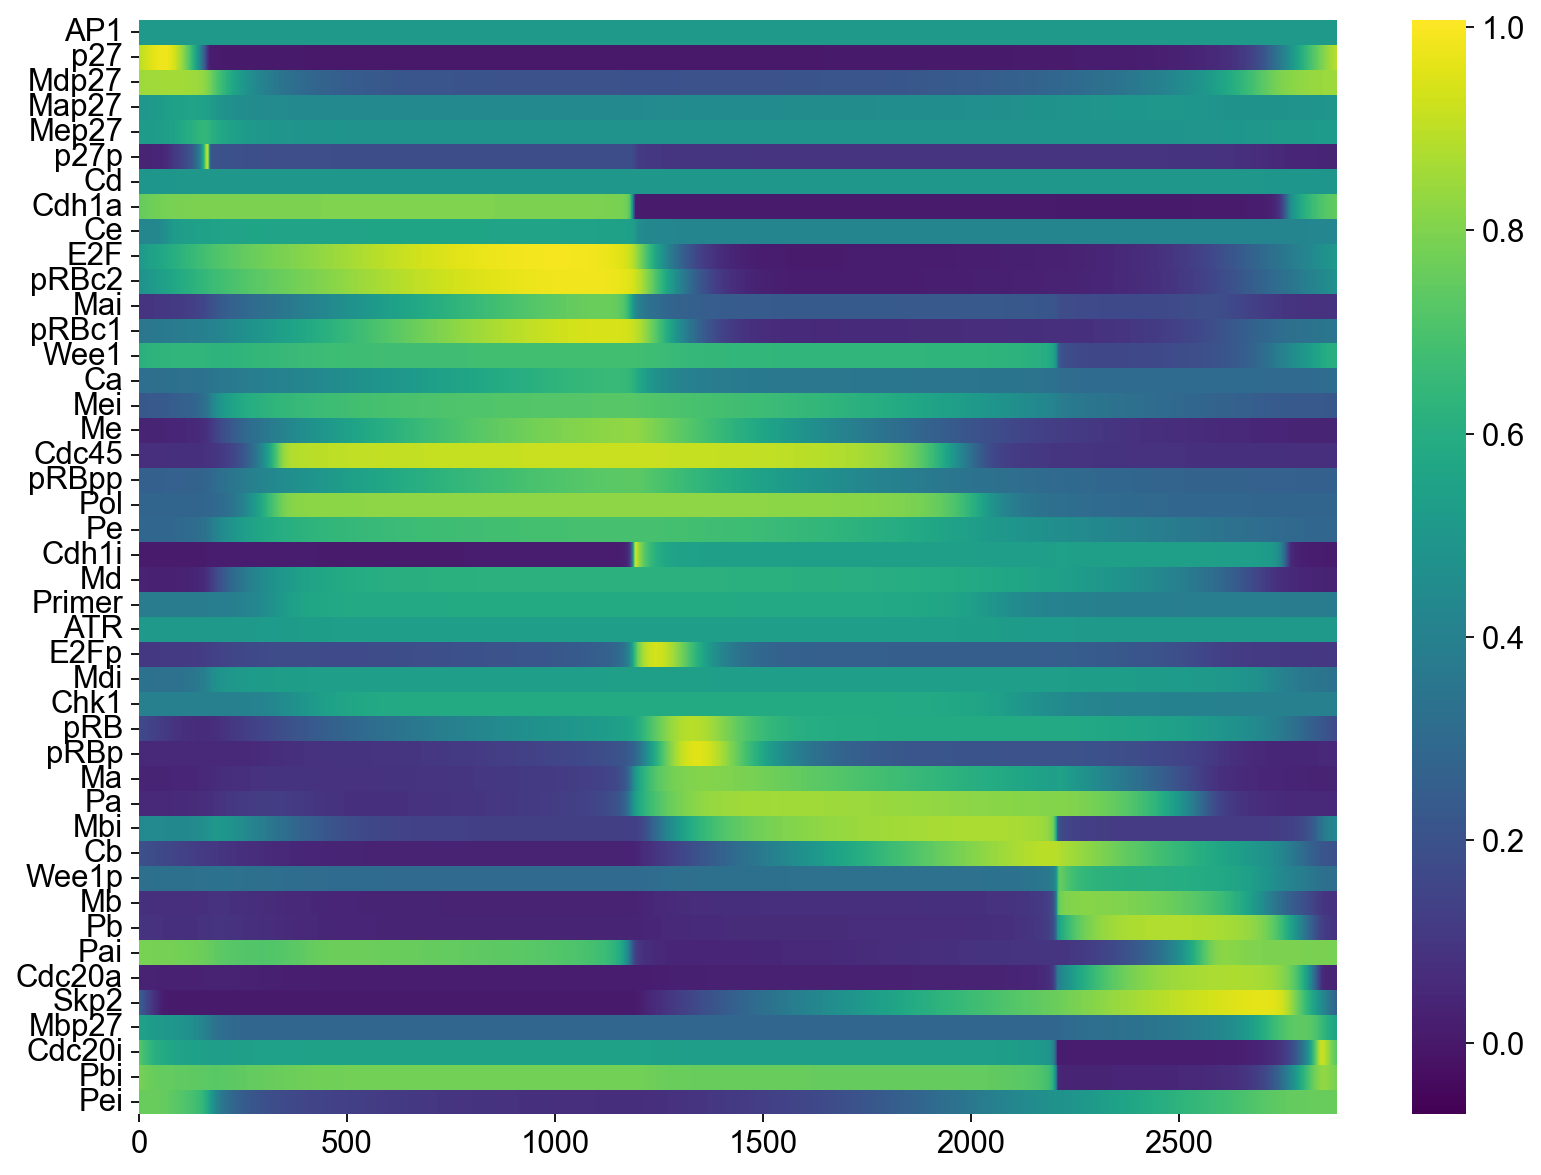

In [26]:
plt.figure(figsize=(12, 9))
sns.heatmap(cycle_true_sorted, cmap='viridis', vmin=vmin, vmax=vmax,
            xticklabels=500, yticklabels=gene_names_sorted, cbar=True)

<Axes: >

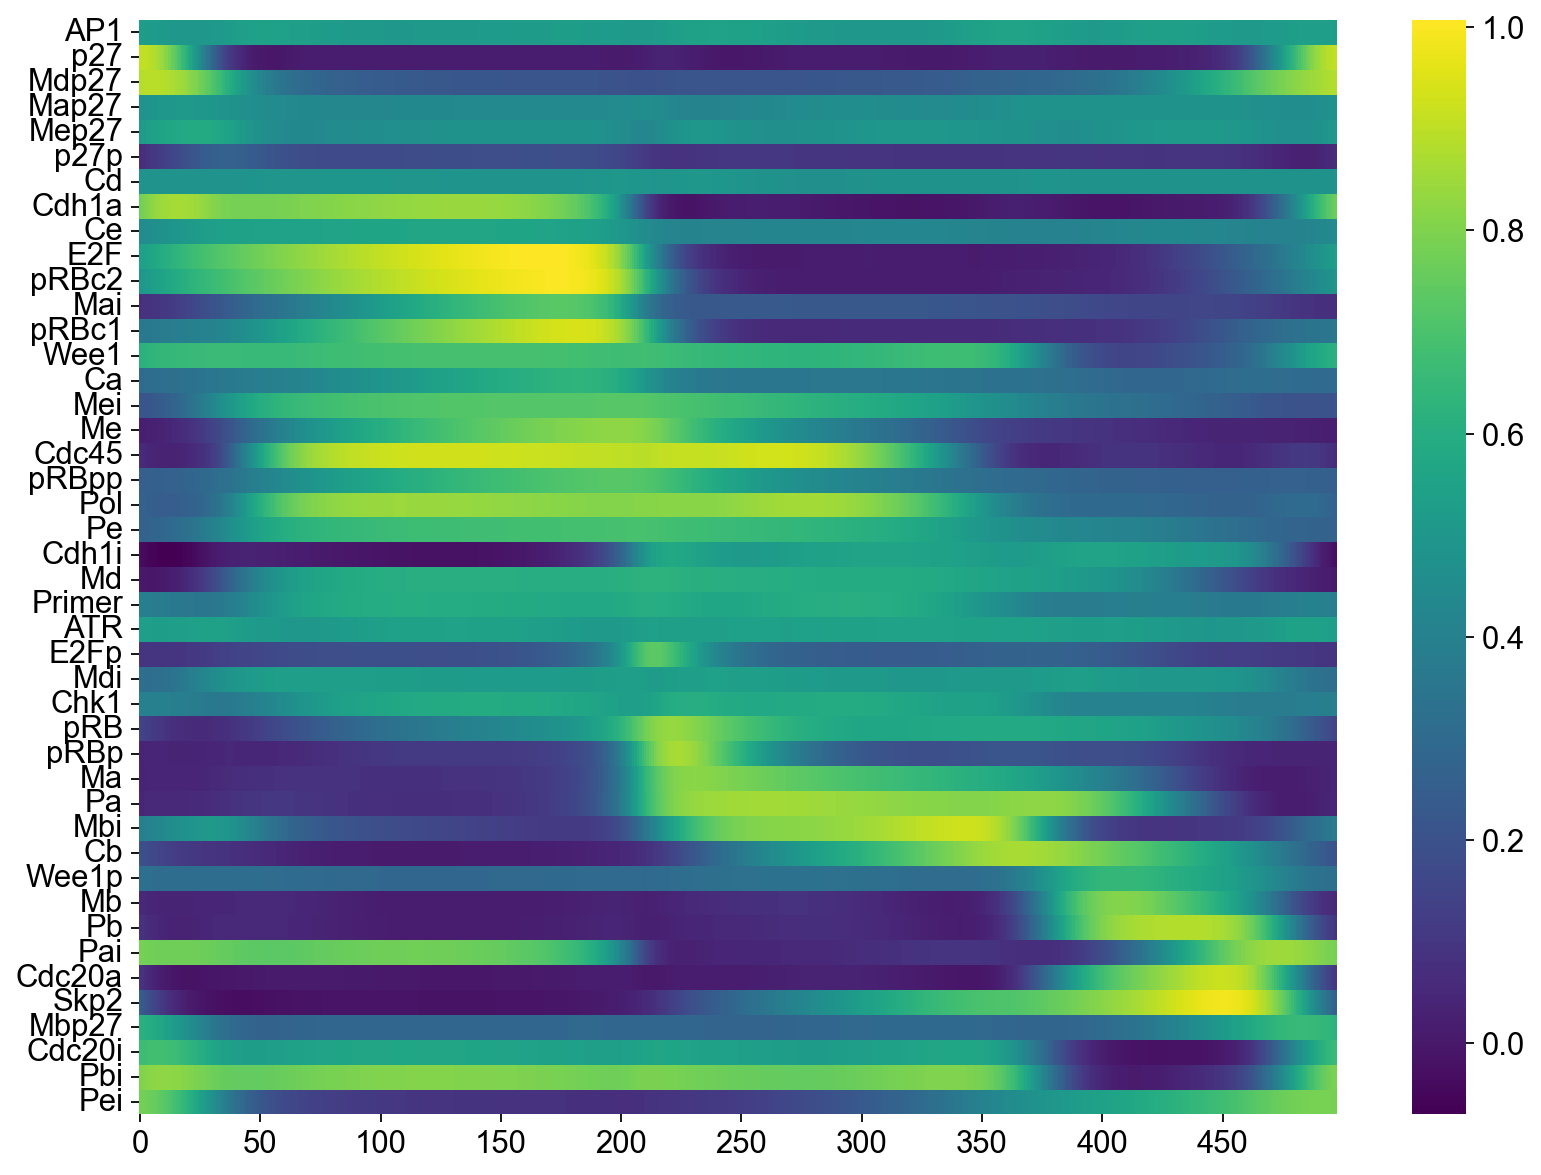

In [27]:
plt.figure(figsize=(12, 9))
sns.heatmap(cycle_VAE_sorted, cmap='viridis', vmin=vmin, vmax=vmax,
            xticklabels=50, yticklabels=gene_names_sorted, cbar=True)

In [28]:
# df = pd.DataFrame(cycle_true, index=gene_names)

# # 使用 clustermap，对行聚类，对列不聚类
# sns.clustermap(df,
#                cmap='viridis',
#                figsize=(20, 12),
#                col_cluster=False,  # 时间点不打乱
#                yticklabels=True,
#                xticklabels=300,    # 控制横轴标签密度（也可设为 False）
#                robust=True         # 抑制极端值影响颜色范围
#               )

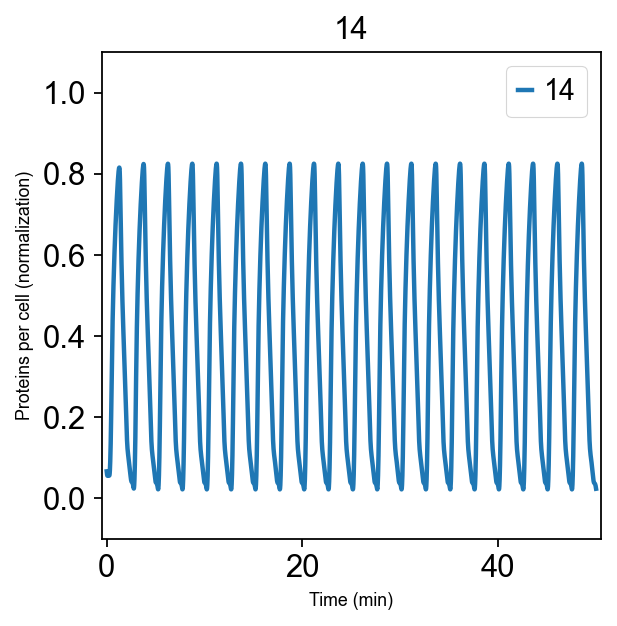

In [29]:
index = 14
plt.plot(t, xx[index,:], label=str(index), linewidth=2.0)
plt.ylim(-0.1, 1.1)
plt.xlim(-10 * 0.05, 1010 * 0.05)
plt.xlabel("Time (min)", fontsize=8, family='Arial')
plt.ylabel("Proteins per cell (normalization)", fontsize=8, family='Arial')
plt.title(str(index))
plt.legend()

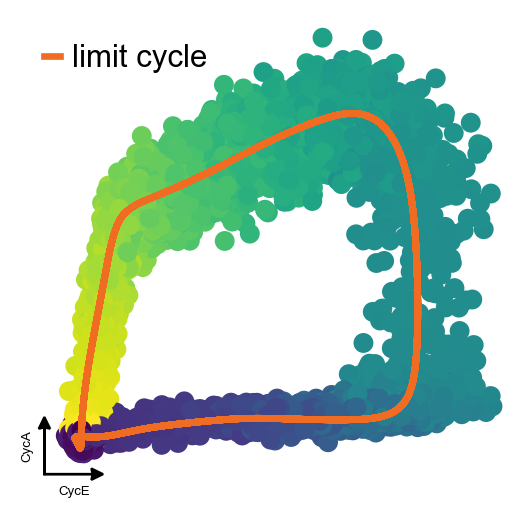

In [30]:
index1 = 14
index2 = 21
fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(xx[index1, 5000:], xx[index2, 5000:], linewidth=3.0, color='#f16c23', label='limit cycle')
ax.scatter(np_data[:, index1], np_data[:, index2], c=th, cmap=cm.viridis, s=80, alpha=1, edgecolors='none', rasterized=True)
arrowed_spines(ax, columns=['CycE','CycA'])
ax.legend(loc='best', fontsize=14, frameon=False)
plt.savefig('figures/limit_cycle_2dim.svg', bbox_inches='tight', transparent=True, dpi=300)
plt.show()

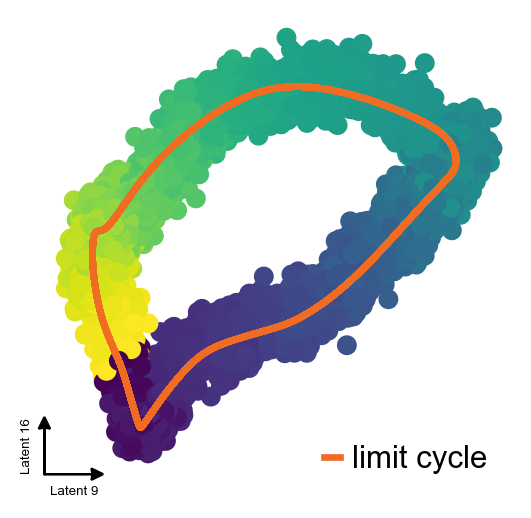

In [31]:
## 绘制latent space轨迹
index1 = 8
index2 = 15
fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(latent_t[index1, 5000:], latent_t[index2, 5000:], linewidth=3.0, color='#f16c23', label='limit cycle')
ax.scatter(latent_z[:, index1], latent_z[:, index2], c=th, cmap=cm.viridis, s=80, alpha=1, edgecolors='none', rasterized=True)
arrowed_spines(ax, columns=['Latent 9','Latent 16'])
ax.legend(loc='best', fontsize=14, frameon=False)
plt.savefig('figures/limit_cycle_latent.svg', bbox_inches='tight', transparent=True, dpi=300)
plt.show()

Text(0.5, 1.0, 'velocity_nODE')

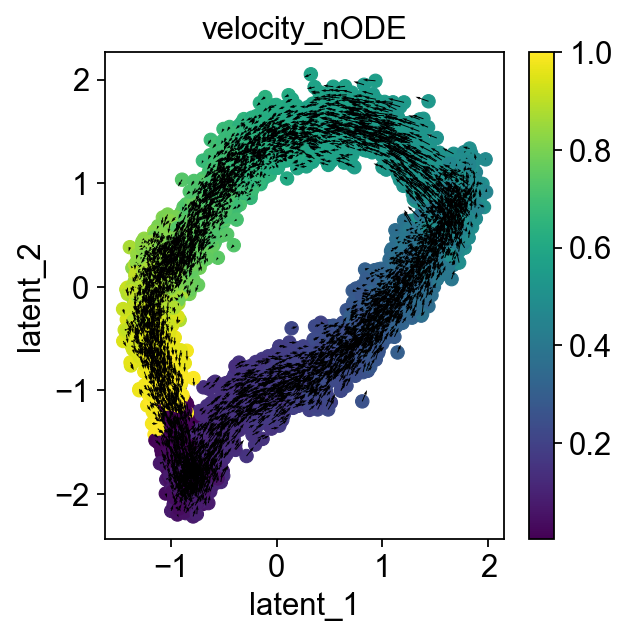

In [32]:
plt.scatter(latent_z[:, index1], latent_z[:, index2],c=th,cmap=cm.viridis)
plt.quiver(latent_z[:, index1], latent_z[:, index2], velocity[:, index1], velocity[:, index2],scale=70, scale_units='xy')
plt.colorbar(mapper, ax=plt.gca())
plt.xlabel("latent_1")
plt.ylabel("latent_2")
plt.title('velocity_nODE')
# plt.savefig('latent.png', dpi=300)

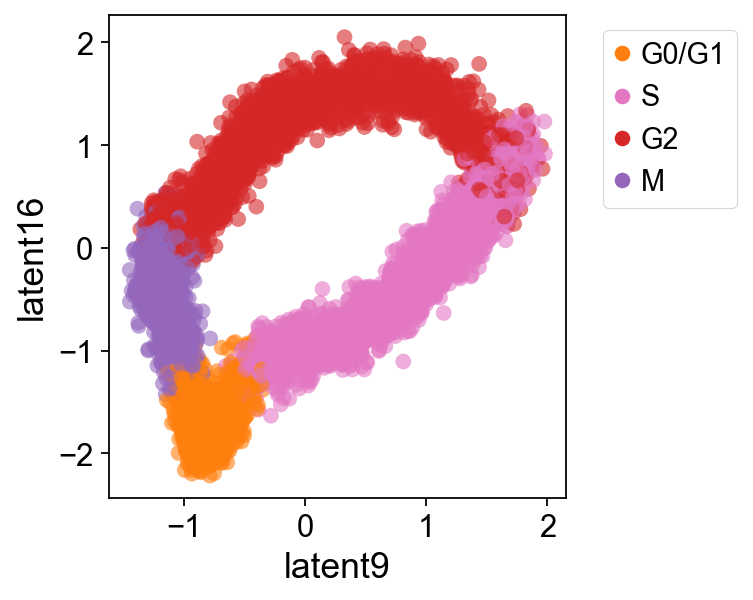

In [33]:
index1 = 8
index2 = 15

plt.figure(figsize=(5, 4))
plt.scatter(latent_z[:, index1], latent_z[:, index2], c=phase_colors, s=50, alpha=0.6, edgecolors='none', rasterized=True)

handles = [Line2D([0], [0], marker='o', color='w',
                  markerfacecolor=color_dict[label], markersize=8, label=label)
           for label in phase_labels]
plt.legend(handles=handles, title='', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=13)
plt.xlabel('latent9', fontsize=16)
plt.ylabel('latent16', fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=14)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig('figures/phase_label.svg', bbox_inches='tight', transparent=True, dpi=300)
plt.show()

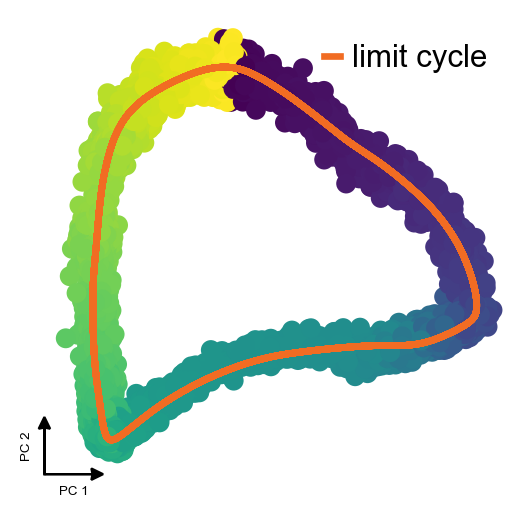

In [34]:
latent_t_pca = ((latent_t.T - np.mean(latent_z, axis=0)) @ V).T
latent_true_pca = ((latent_true.T - np.mean(latent_z, axis=0)) @ V).T
fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(latent_t_pca[0, 5000:], latent_t_pca[1, 5000:], linewidth=3.0, color='#f16c23', label='limit cycle')
ax.scatter(latent_z_pca[:, 0], latent_z_pca[:, 1], c=th, cmap=cm.viridis, s=80, alpha=1, edgecolors='none', rasterized=True)

arrowed_spines(ax, columns='PC')
ax.legend(loc='best', fontsize=14, frameon=False)
plt.savefig('figures/limit_cycle_PC.svg', bbox_inches='tight', transparent=True, dpi=300)
plt.show()

Text(0.5, 1.0, 'velocity_nODE')

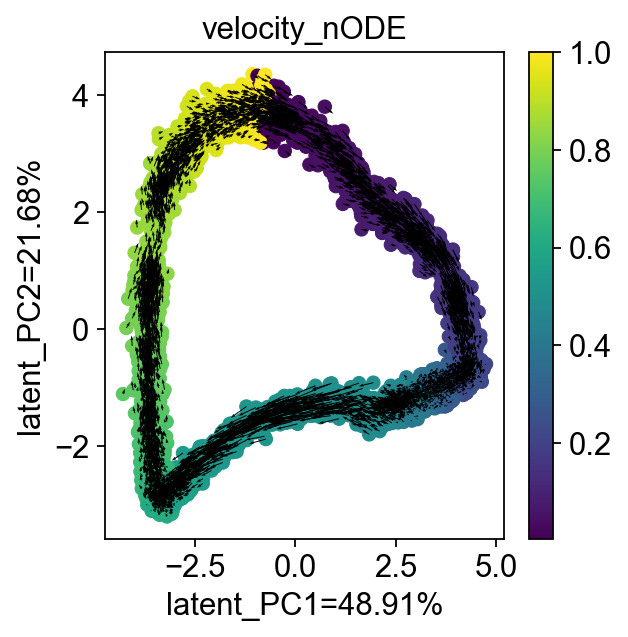

In [35]:
plt.scatter(latent_z_pca[:, 0], latent_z_pca[:, 1],c=th,cmap=cm.viridis)
plt.quiver(latent_z_pca[:, 0], latent_z_pca[:, 1], v_pca[:, 0], v_pca[:, 1],scale=70, scale_units='xy')
plt.colorbar(mapper, ax=plt.gca())
plt.xlabel(f'latent_PC1={ratio[0] * 100:.2f}%')
plt.ylabel(f'latent_PC2={ratio[1] * 100:.2f}%')
plt.title('velocity_nODE')
# plt.savefig('latent.png', dpi=300)

In [36]:
## 创建一个adata数据
latent_adata = ad.AnnData(latent_z, 
                          obsm={'X_z': latent_z},
                          layers = {'spliced': latent_z,
                                   'spliced_velocity': velocity},
                          )

latent_adata.obs['pseudotime'] = pseudotime
latent_adata

AnnData object with n_obs × n_vars = 8000 × 20
    obs: 'pseudotime'
    obsm: 'X_z'
    layers: 'spliced', 'spliced_velocity'

In [37]:
latent_adata.obsm['X_pca'] = latent_z_pca
latent_adata.obsm['velocity_pca'] = v_pca
latent_adata.obsm['X_2dim'] = latent_z[:,[8,15]]
latent_adata.obsm['velocity_2dim'] = velocity[:,[8,15]]
latent_adata.uns["velocity_params"] = {'embeddings':['pca','2dim']}

saving figure to file figures/streamplot_latent_PC.svg


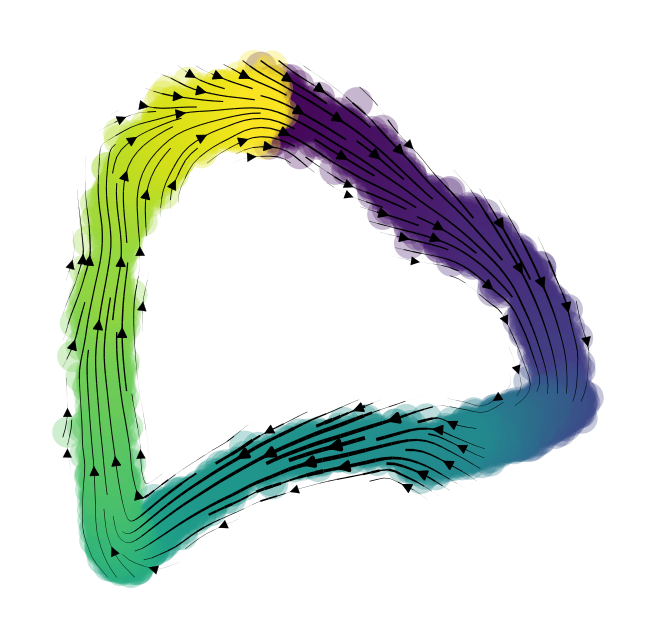

In [38]:
scv.pl.velocity_embedding_stream(
    latent_adata, size=800,
    density=2, smooth=0.5, min_mass=1,
    basis='pca', 
    color='pseudotime', 
    title="",
    fontsize=14,
    color_map='viridis',
    colorbar=False,
    figsize=(5,5),add_margin=0.1,rasterized=True,
    save='figures/streamplot_latent_PC.svg'
)

saving figure to file figures/streamplot_latent.svg


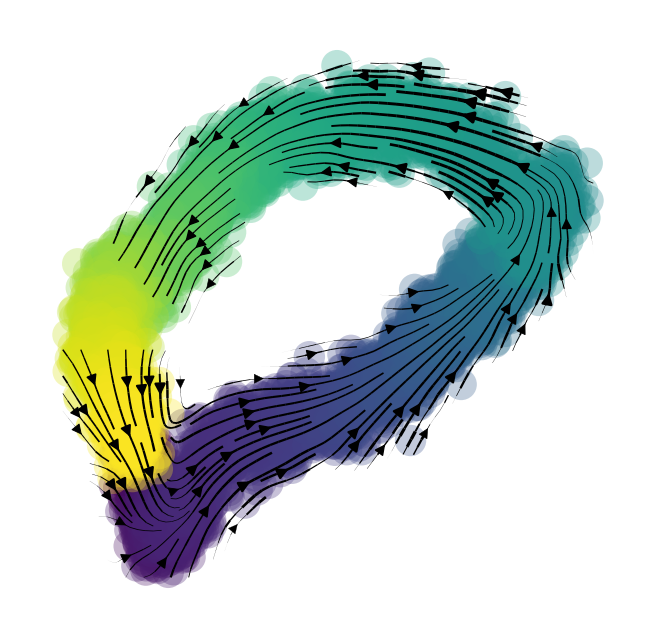

In [39]:
scv.pl.velocity_embedding_stream(
    latent_adata, size=800,
    density=2, smooth=0.5, min_mass=1,
    basis='2dim', 
    color='pseudotime', 
    title="",
    fontsize=14,
    color_map='viridis',
    colorbar=False,
    figsize=(5,5),add_margin=0.1,rasterized=True,
    save='figures/streamplot_latent.svg'
)

In [40]:
# jacobians = np.zeros((20, 20, 10000))
# for i in range(10000):
#     x1 = torch.as_tensor(latent_t[:,i].reshape(-1, 20), dtype=torch.float32)
#     jac = jacobian(dynamics_learner, x1).squeeze()
#     jacobians[:, :, i] = jac.detach().numpy()

In [41]:
# sigma = np.zeros(10000)
# sigma0 = 0
# for i in range(10000):
#     sigma[i] = sigma0
#     d_sigma = 2 * jacobians[1,1,i] * sigma0 + 2 * 0.5
#     sigma0 += 0.005 * d_sigma